# Medical Insurance Analysis — Visualizations



In [32]:
# Import all required libraries and configure global plot styling, colors, and chart resolution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

PALETTE = "viridis"
ACCENT = "#2E86AB"
ACCENT2 = "#E63946"
df = pd.read_csv(r"C:\Users\Radwa\Downloads\archive (1)\medical_insurance.csv")
df.head()


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [5]:
# Create all derived columns needed for the charts: age groups, cost ranges, regional averages,
# risk profiles, cost deciles, loss ratio, smoker labels, and cumulative cost curves

def age_group(age):
    if age < 30:
        return "Young"
    elif age < 45:
        return "Middle"
    elif age < 60:
        return "Senior"
    else:
        return "Elder"

df["age_group"] = df["age"].apply(age_group)
df["age_group"] = pd.Categorical(df["age_group"], categories=["Young", "Middle", "Senior", "Elder"], ordered=True)

bins = [0, 5000, 10000, 20000, 50000, float("inf")]
labels = ["0-5K", "5K-10K", "10K-20K", "20K-50K", "50K+"]
df["cost_range"] = pd.cut(df["annual_medical_cost"], bins=bins, labels=labels)

df["region_avg"] = df.groupby("region")["annual_medical_cost"].transform("mean")
df["diff_from_avg"] = df["annual_medical_cost"] - df["region_avg"]

def risk_profile(row):
    if row["smoker"] == 1 and row["bmi"] >= 30 and row["age"] >= 45:
        return "Very High Risk"
    elif row["smoker"] == 1 and row["bmi"] >= 30:
        return "High Risk"
    elif row["smoker"] == 1 or row["bmi"] >= 30:
        return "Medium Risk"
    else:
        return "Low Risk"

df["risk_profile"] = df.apply(risk_profile, axis=1)
df["risk_profile"] = pd.Categorical(
    df["risk_profile"], categories=["Low Risk", "Medium Risk", "High Risk", "Very High Risk"], ordered=True
)

df["cost_decile"] = pd.qcut(df["annual_medical_cost"], 10, labels=False, duplicates="drop")
df["loss_ratio"] = df["annual_medical_cost"] / df["annual_premium"]
df["smoker_label"] = df["smoker"].map({0: "Non-Smoker", 1: "Smoker"})

df_sorted = df.sort_values("annual_medical_cost", ascending=False).reset_index(drop=True)
df_sorted["cumulative_cost"] = df_sorted["annual_medical_cost"].cumsum()
df_sorted["pct_of_total"] = df_sorted["annual_medical_cost"] / df_sorted["annual_medical_cost"].sum() * 100
df_sorted["cumulative_pct"] = df_sorted["cumulative_cost"] / df_sorted["annual_medical_cost"].sum() * 100
df_sorted["pct_of_population"] = (df_sorted.index + 1) / len(df_sorted) * 100

def fmt_k(x, pos=None):
    return f"${x/1000:,.0f}K"

print("Dataset ready:", df.shape[0], "rows,", df.shape[1], "columns")

Dataset ready: 100000 rows, 62 columns


## Dashboard

C:\Users\Radwa\AppData\Local\Temp\ipykernel_1276592\2493751222.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cost_age = df.groupby('age_group')['annual_medical_cost'].mean()


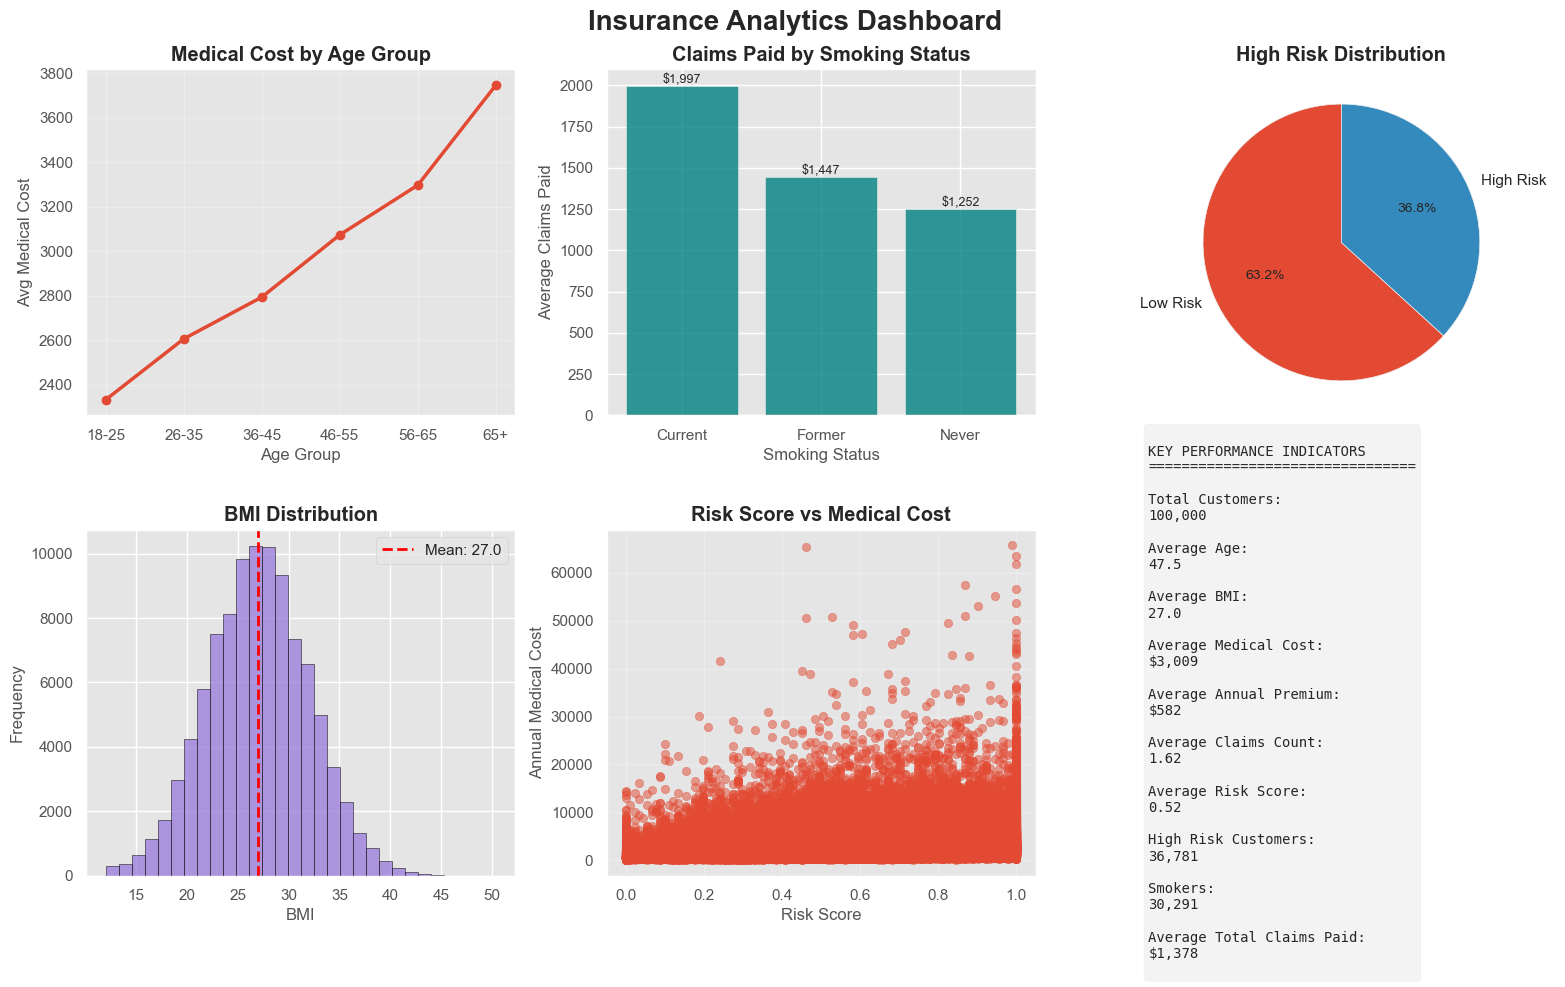

In [19]:
# Build a 6-panel summary dashboard: cost by age, claims by smoking, risk pie chart,
# BMI histogram, risk score scatter, and a KPI text box

plt.style.use('ggplot')
fig = plt.figure(figsize=(16,10))

fig.suptitle(
    'Insurance Analytics Dashboard',
    fontsize=20,
    fontweight='bold',
    y=0.98
)

# =====================================
# 1. Medical Cost by Age Group
# =====================================

ax1 = plt.subplot(2,3,1)

cost_age = df.groupby('age_group')['annual_medical_cost'].mean()

ax1.plot(
    cost_age.index.astype(str),
    cost_age.values,
    marker='o',
    linewidth=2.5
)

ax1.set_title('Medical Cost by Age Group', fontweight='bold')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Avg Medical Cost')
ax1.grid(True, alpha=0.3)

# =====================================
# 2. Claims Paid by Smoking Status
# =====================================

ax2 = plt.subplot(2,3,2)

smoker_claims = df.groupby('smoker')['total_claims_paid'].mean()

bars = ax2.bar(
    smoker_claims.index,
    smoker_claims.values,
    color='teal',
    alpha=0.8
)

ax2.set_title('Claims Paid by Smoking Status', fontweight='bold')
ax2.set_xlabel('Smoking Status')
ax2.set_ylabel('Average Claims Paid')

for bar in bars:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'${height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# =====================================
# 3. High Risk Distribution
# =====================================

ax3 = plt.subplot(2,3,3)

risk_counts = df['is_high_risk'].value_counts()

ax3.pie(
    risk_counts,
    labels=['Low Risk','High Risk'],
    autopct='%1.1f%%',
    startangle=90
)

ax3.set_title('High Risk Distribution', fontweight='bold')

# =====================================
# 4. BMI Distribution
# =====================================

ax4 = plt.subplot(2,3,4)

ax4.hist(
    df['bmi'],
    bins=30,
    color='mediumpurple',
    alpha=0.7,
    edgecolor='black'
)

ax4.axvline(
    df['bmi'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {df["bmi"].mean():.1f}'
)

ax4.legend()

ax4.set_title('BMI Distribution', fontweight='bold')
ax4.set_xlabel('BMI')
ax4.set_ylabel('Frequency')

# =====================================
# 5. Risk Score vs Medical Cost
# =====================================

ax5 = plt.subplot(2,3,5)

ax5.scatter(
    df['risk_score'],
    df['annual_medical_cost'],
    alpha=0.5
)

ax5.set_title('Risk Score vs Medical Cost', fontweight='bold')
ax5.set_xlabel('Risk Score')
ax5.set_ylabel('Annual Medical Cost')
ax5.grid(True, alpha=0.3)

# =====================================
# 6. KPI Summary
# =====================================

ax6 = plt.subplot(2,3,6)
ax6.axis('off')

metrics_text = f"""
KEY PERFORMANCE INDICATORS
================================

Total Customers:
{len(df):,}

Average Age:
{df['age'].mean():.1f}

Average BMI:
{df['bmi'].mean():.1f}

Average Medical Cost:
${df['annual_medical_cost'].mean():,.0f}

Average Annual Premium:
${df['annual_premium'].mean():,.0f}

Average Claims Count:
{df['claims_count'].mean():.2f}

Average Risk Score:
{df['risk_score'].mean():.2f}

High Risk Customers:
{df['is_high_risk'].sum():,}

Smokers:
{(df['smoker'] != 'Never').sum():,}

Average Total Claims Paid:
${df['total_claims_paid'].mean():,.0f}
"""

ax6.text(
    0.05,
    0.5,
    metrics_text,
    fontsize=10,
    family='monospace',
    verticalalignment='center',
    bbox=dict(
        boxstyle='round',
        facecolor='#f0f0f0',
        alpha=0.8
    )
)

plt.tight_layout()
plt.show()

## Distribution of annual medical cost

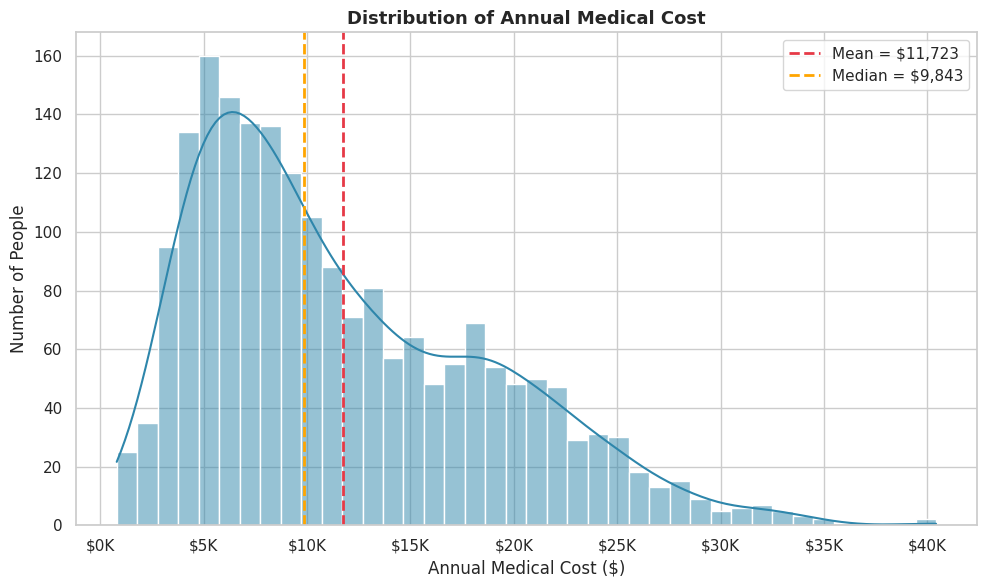

In [3]:
# Plot the distribution of annual medical cost as a histogram with a KDE curve,
# and mark the mean and median with vertical dashed lines
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df["annual_medical_cost"], bins=40, kde=True, color=ACCENT, ax=ax)
ax.axvline(df["annual_medical_cost"].mean(), color=ACCENT2, linestyle="--", linewidth=2,
           label=f"Mean = ${df['annual_medical_cost'].mean():,.0f}")
ax.axvline(df["annual_medical_cost"].median(), color="orange", linestyle="--", linewidth=2,
           label=f"Median = ${df['annual_medical_cost'].median():,.0f}")
ax.set_title("Distribution of Annual Medical Cost")
ax.set_xlabel("Annual Medical Cost ($)")
ax.set_ylabel("Number of People")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.legend()
plt.tight_layout()
plt.show()

## Statistical Summary of Annual Medical Cost

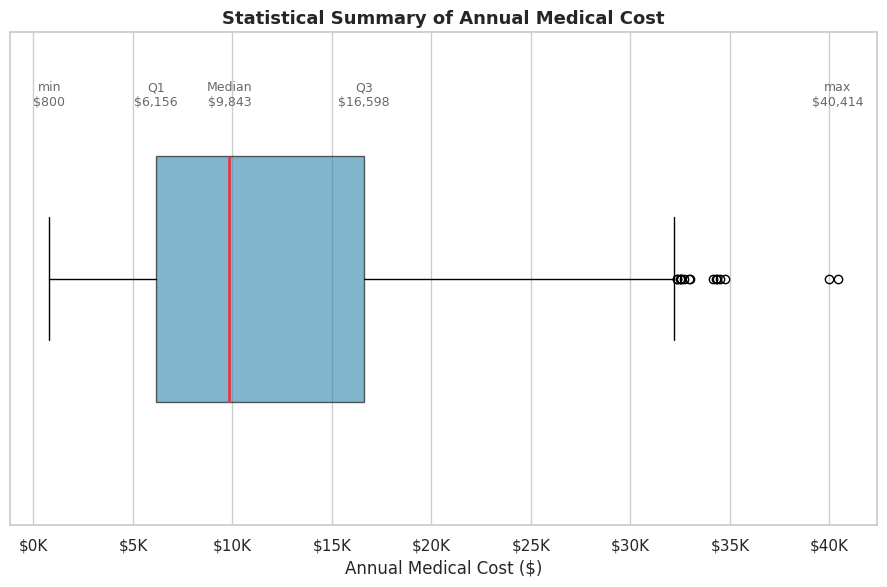

In [4]:
# Draw a horizontal boxplot of annual medical cost annotated with the five key statistics
# (min, Q1, median, Q3, max)
stats = {
    "min": df["annual_medical_cost"].min(), "Q1": df["annual_medical_cost"].quantile(0.25),
    "Median": df["annual_medical_cost"].quantile(0.50), "Q3": df["annual_medical_cost"].quantile(0.75),
    "max": df["annual_medical_cost"].max()
}
fig, ax = plt.subplots(figsize=(9, 6))
ax.boxplot(df["annual_medical_cost"], vert=False, widths=0.5, patch_artist=True,
           boxprops=dict(facecolor=ACCENT, alpha=0.6), medianprops=dict(color=ACCENT2, linewidth=2))
ax.set_yticks([])
ax.set_xlabel("Annual Medical Cost ($)")
ax.set_title("Statistical Summary of Annual Medical Cost")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
for label, val in stats.items():
    ax.annotate(f"{label}\n${val:,.0f}", xy=(val, 1), xytext=(val, 1.35), ha="center", fontsize=9, color="dimgray")
plt.tight_layout()
plt.show()

## Number of People by Cost Range 

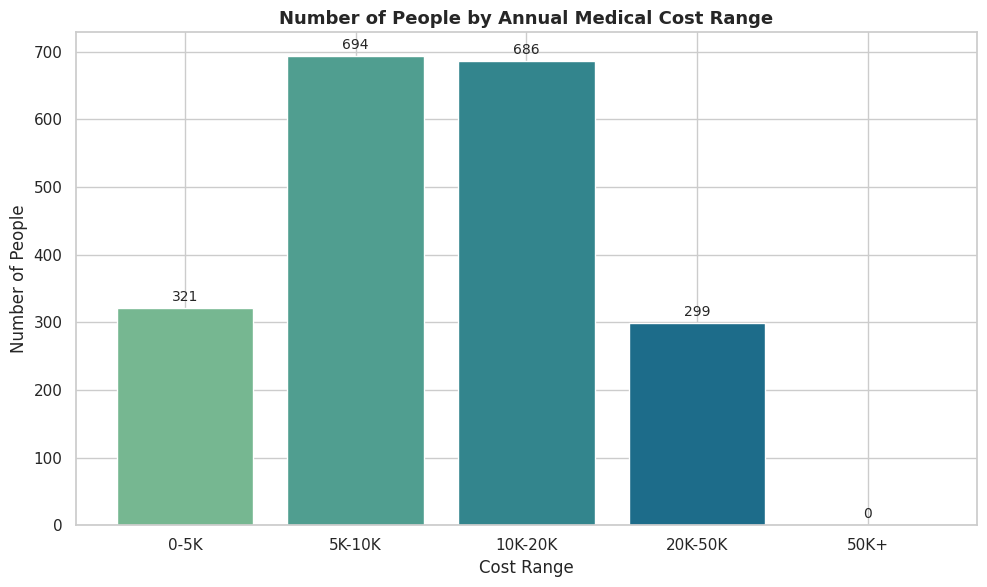

In [5]:
# Bar chart showing how many people fall into each cost range bucket (0-5K, 5K-10K, etc.)
cost_range_counts = df["cost_range"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(cost_range_counts.index.astype(str), cost_range_counts.values, color=sns.color_palette("crest", len(cost_range_counts)))
ax.set_title("Number of People by Annual Medical Cost Range")
ax.set_xlabel("Cost Range")
ax.set_ylabel("Number of People")
for bar, val in zip(bars, cost_range_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10, str(val), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

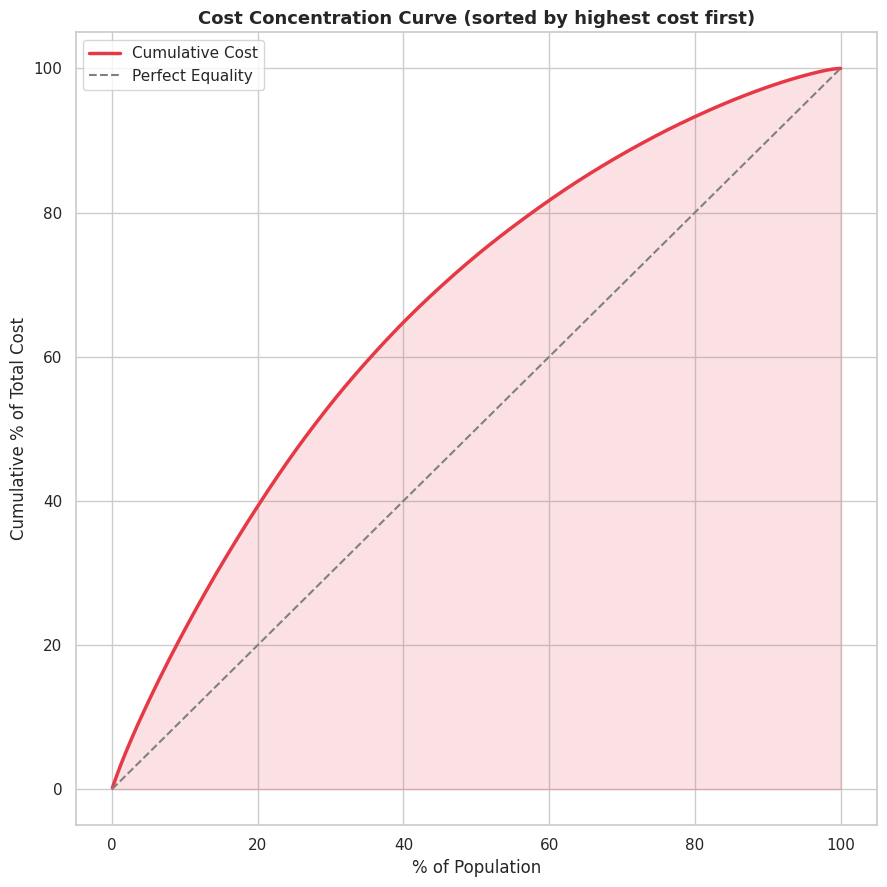

In [6]:
# Lorenz-style curve: shows what share of total cost is driven by the most expensive share of the population
fig, ax = plt.subplots(figsize=(9, 9))
ax.plot(df_sorted["pct_of_population"], df_sorted["cumulative_pct"], color=ACCENT2, linewidth=2.5, label="Cumulative Cost")
ax.plot([0, 100], [0, 100], color="gray", linestyle="--", label="Perfect Equality")
ax.fill_between(df_sorted["pct_of_population"], df_sorted["cumulative_pct"], alpha=0.15, color=ACCENT2)
ax.set_title("Cost Concentration Curve (sorted by highest cost first)")
ax.set_xlabel("% of Population")
ax.set_ylabel("Cumulative % of Total Cost")
ax.legend()
plt.tight_layout()
plt.show()

## Demographics: Age, Sex & Region

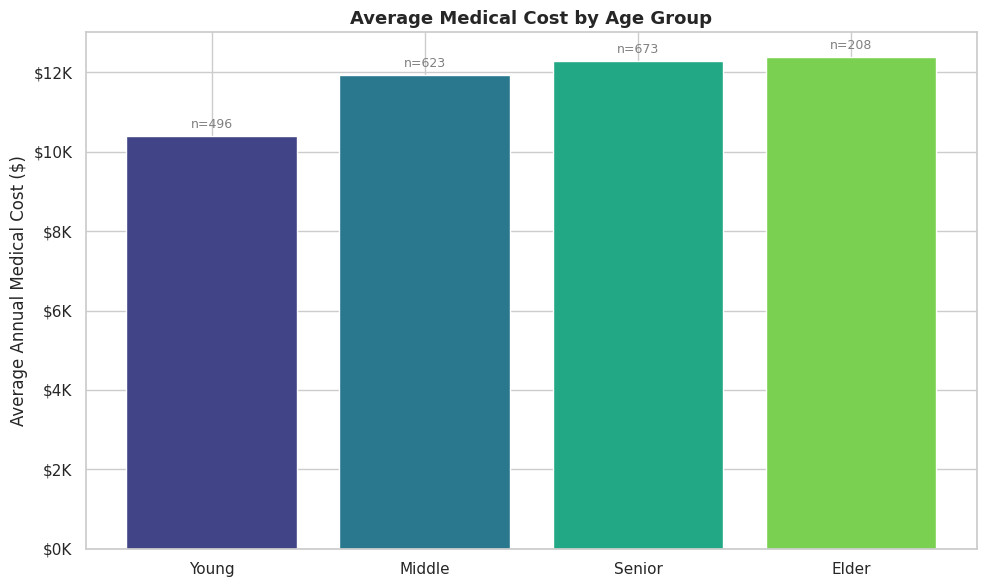

In [7]:
# Bar chart of average medical cost per age group with sample sizes labeled above each bar
age_analysis = df.groupby("age_group").agg(total=("age_group", "count"), avg_cost=("annual_medical_cost", "mean")).round(2)
fig, ax1 = plt.subplots(figsize=(10, 6))
x = np.arange(len(age_analysis))
bars = ax1.bar(x, age_analysis["avg_cost"], color=sns.color_palette(PALETTE, len(age_analysis)))
ax1.set_xticks(x)
ax1.set_xticklabels(age_analysis.index)
ax1.set_ylabel("Average Annual Medical Cost ($)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax1.set_title("Average Medical Cost by Age Group")
for bar, total in zip(bars, age_analysis["total"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f"n={total}", ha="center", fontsize=9, color="gray")
plt.tight_layout()
plt.show()

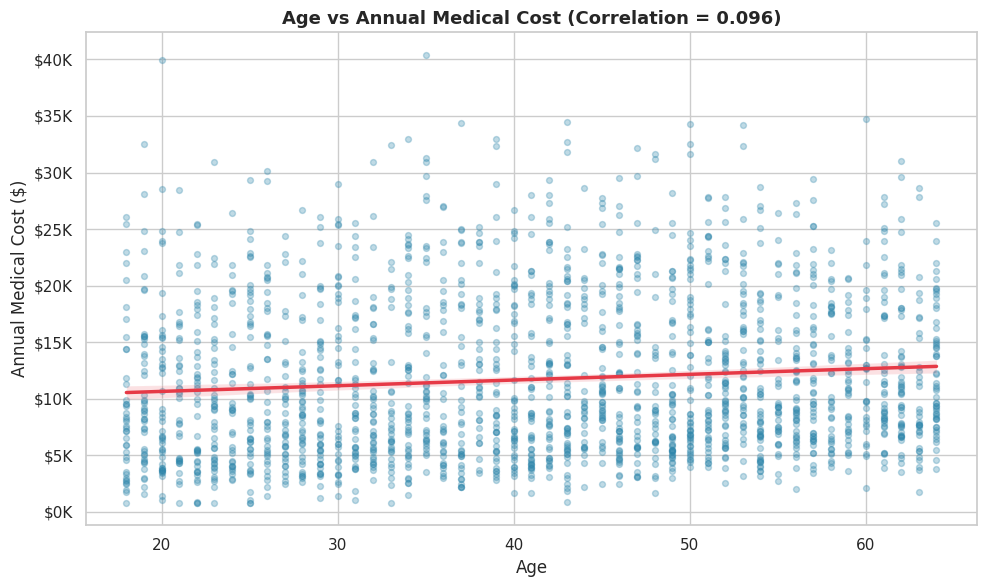

In [8]:
# Scatter plot with regression line showing the relationship between age and annual medical cost,
# with the correlation coefficient displayed in the title
correlation = df["age"].corr(df["annual_medical_cost"])
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=df, x="age", y="annual_medical_cost", scatter_kws={"alpha": 0.3, "s": 18, "color": ACCENT},
            line_kws={"color": ACCENT2, "linewidth": 2.5}, ax=ax)
ax.set_title(f"Age vs Annual Medical Cost (Correlation = {correlation:.3f})")
ax.set_xlabel("Age")
ax.set_ylabel("Annual Medical Cost ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
plt.tight_layout()
plt.show()

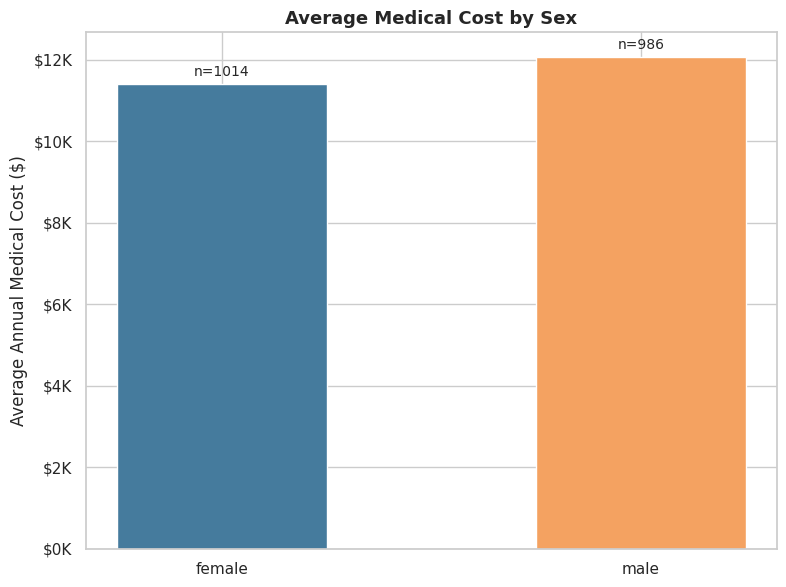

In [9]:
# Bar chart comparing average medical cost between male and female members,
# with sample sizes labeled on top of each bar
sex_analysis = df.groupby("sex").agg(total=("sex", "count"), avg_cost=("annual_medical_cost", "mean"), avg_bmi=("bmi", "mean")).round(2)
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(sex_analysis.index, sex_analysis["avg_cost"], color=["#457B9D", "#F4A261"], width=0.5)
ax.set_title("Average Medical Cost by Sex")
ax.set_ylabel("Average Annual Medical Cost ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
for bar, total in zip(bars, sex_analysis["total"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200, f"n={total}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

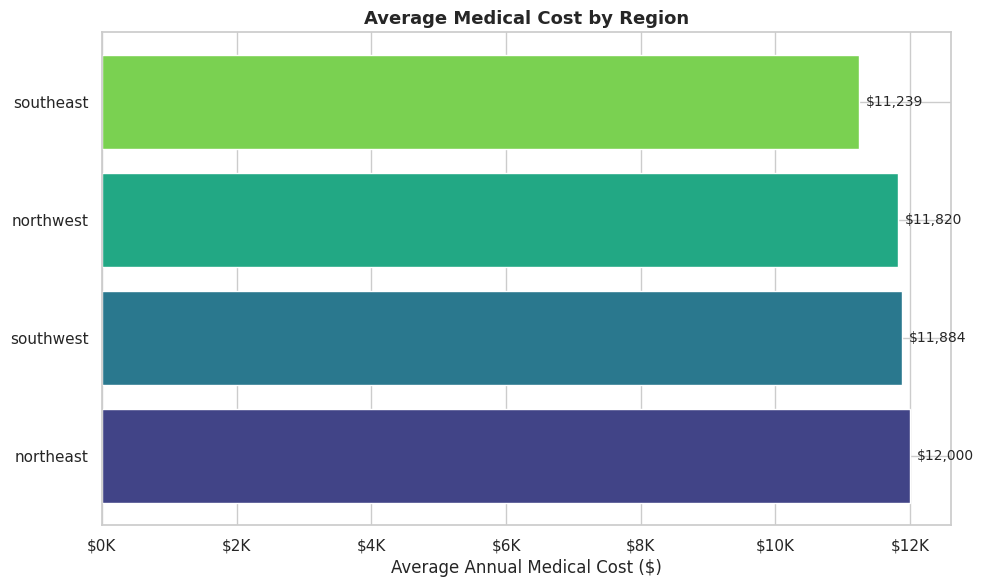

In [10]:
# Horizontal bar chart ranking regions from highest to lowest average annual medical cost
region_analysis = df.groupby("region").agg(
    total_people=("region", "count"), avg_cost=("annual_medical_cost", "mean"), avg_bmi=("bmi", "mean")
).round(2).sort_values("avg_cost", ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(region_analysis.index, region_analysis["avg_cost"], color=sns.color_palette(PALETTE, len(region_analysis)))
ax.set_xlabel("Average Annual Medical Cost ($)")
ax.set_title("Average Medical Cost by Region")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
for bar, val in zip(bars, region_analysis["avg_cost"]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, f"${val:,.0f}", va="center", fontsize=10)
plt.tight_layout()
plt.show()

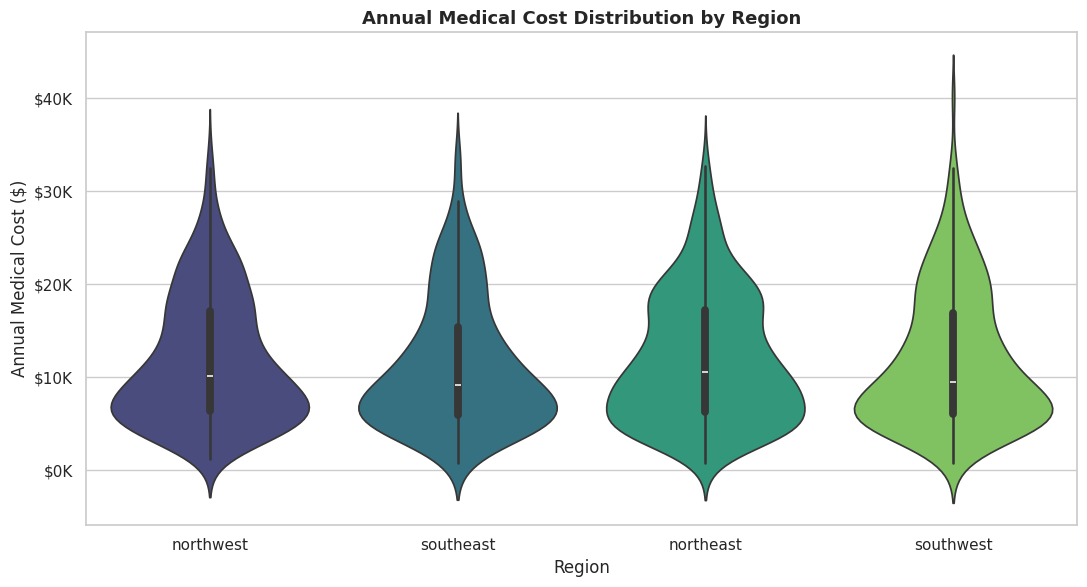

In [11]:
# Violin plot showing the full cost distribution shape per region (not just the average)
fig, ax = plt.subplots(figsize=(11, 6))
sns.violinplot(data=df, x="region", y="annual_medical_cost", hue="region", palette=PALETTE, ax=ax, legend=False)
ax.set_title("Annual Medical Cost Distribution by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Annual Medical Cost ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
plt.tight_layout()
plt.show()

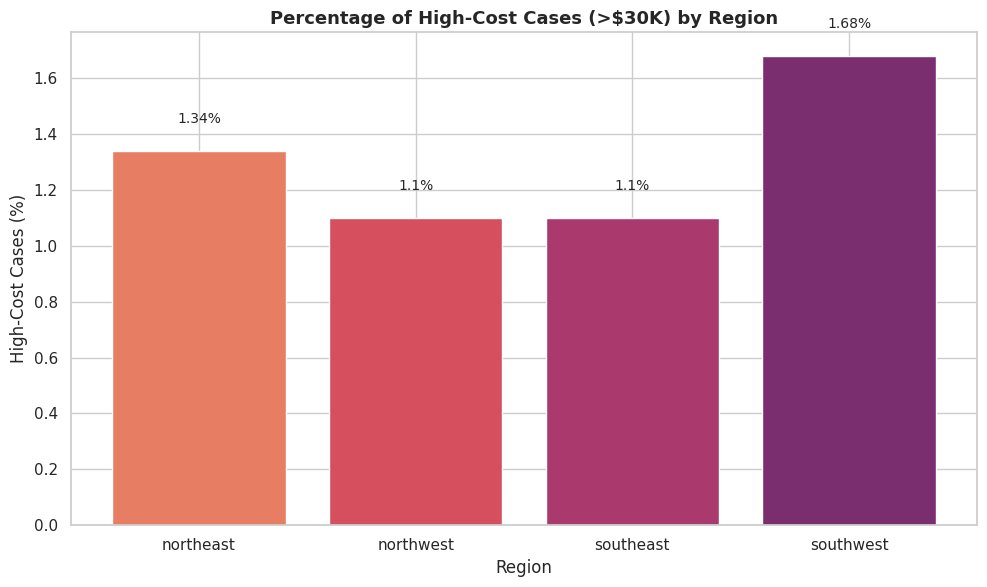

In [12]:
# Bar chart showing the percentage of members in each region whose cost exceeds $30,000
high_cost_region = df.groupby("region").apply(
    lambda x: pd.Series({
        "total_people": len(x),
        "high_cost_cases": (x["annual_medical_cost"] > 30000).sum(),
        "high_cost_pct": round((x["annual_medical_cost"] > 30000).mean()*100, 2)
    }), include_groups=False
)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(high_cost_region.index, high_cost_region["high_cost_pct"], color=sns.color_palette("flare", len(high_cost_region)))
ax.set_title("Percentage of High-Cost Cases (>$30K) by Region")
ax.set_ylabel("High-Cost Cases (%)")
ax.set_xlabel("Region")
for bar, val in zip(bars, high_cost_region["high_cost_pct"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f"{val}%", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

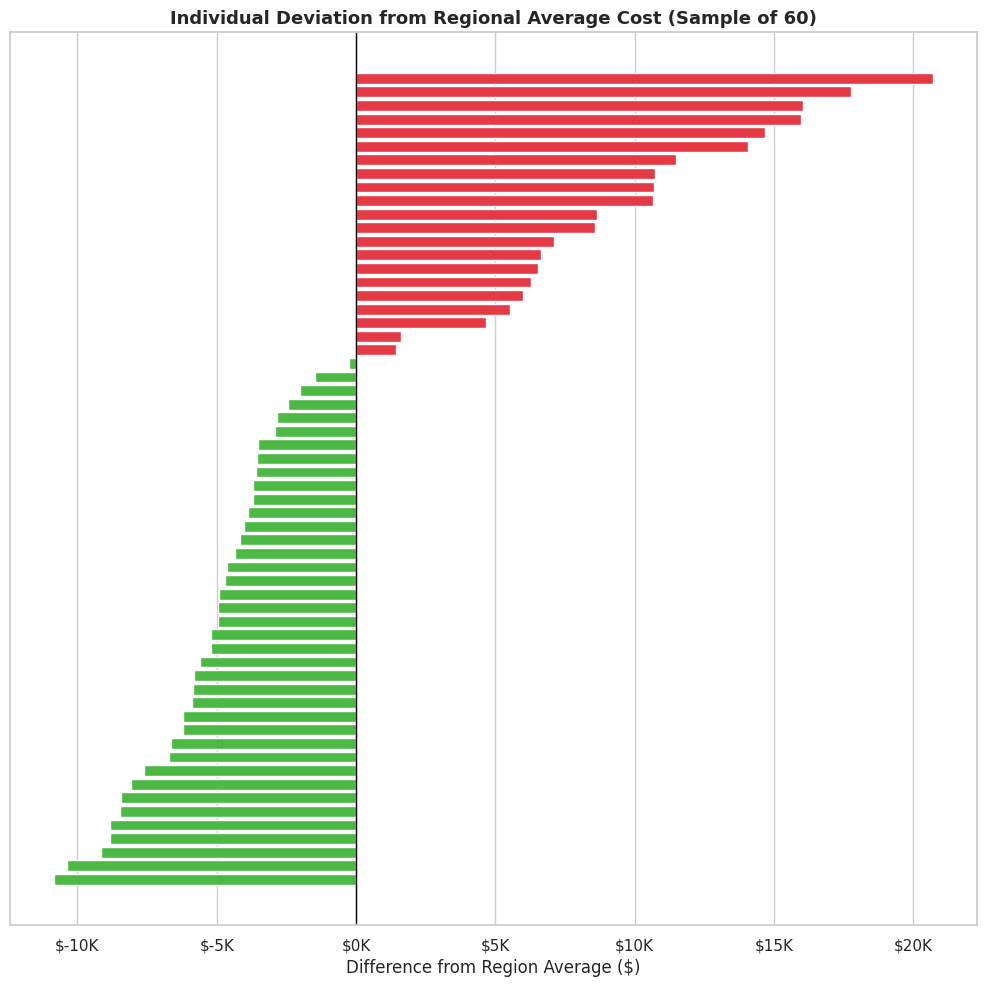

In [13]:
# Diverging bar chart on a sample of 60 people showing whether each individual costs
# more (red) or less (green) than their region's average
sample = df.sample(60, random_state=1).sort_values("diff_from_avg")
colors = ["#E63946" if v > 0 else "#4CB944" for v in sample["diff_from_avg"]]
fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(range(len(sample)), sample["diff_from_avg"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks([])
ax.set_title("Individual Deviation from Regional Average Cost (Sample of 60)")
ax.set_xlabel("Difference from Region Average ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
plt.tight_layout()
plt.show()

## Risk Factors: Smoking, BMI & Chronic Conditions

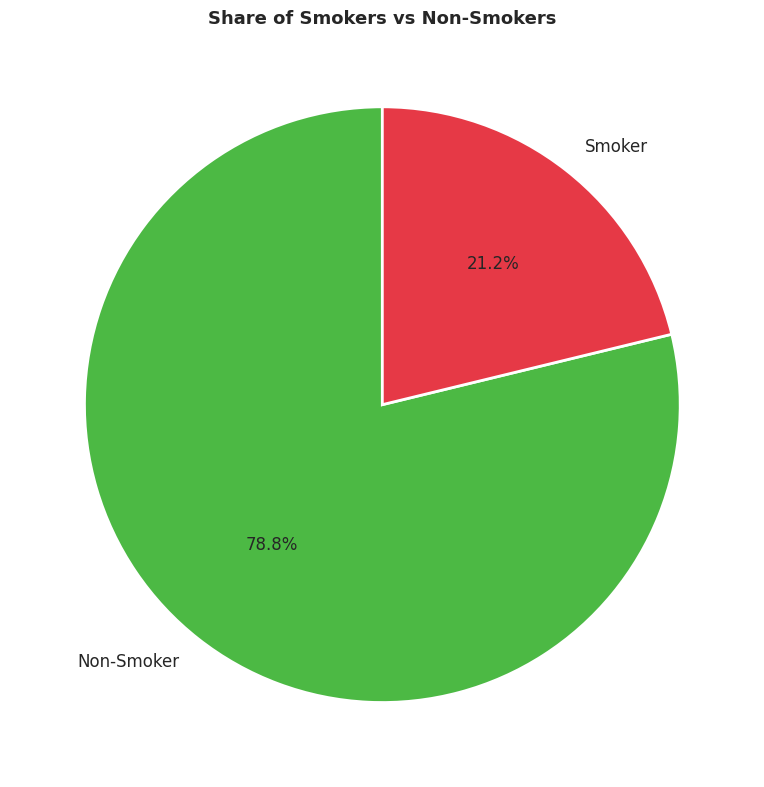

In [14]:
# Pie chart showing the population split between smokers and non-smokers
fig, ax = plt.subplots(figsize=(8, 8))
counts = df["smoker_label"].value_counts()
ax.pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90,
       colors=["#4CB944", "#E63946"], wedgeprops={"edgecolor": "white", "linewidth": 2}, textprops={"fontsize": 12})
ax.set_title("Share of Smokers vs Non-Smokers")
plt.tight_layout()
plt.show()

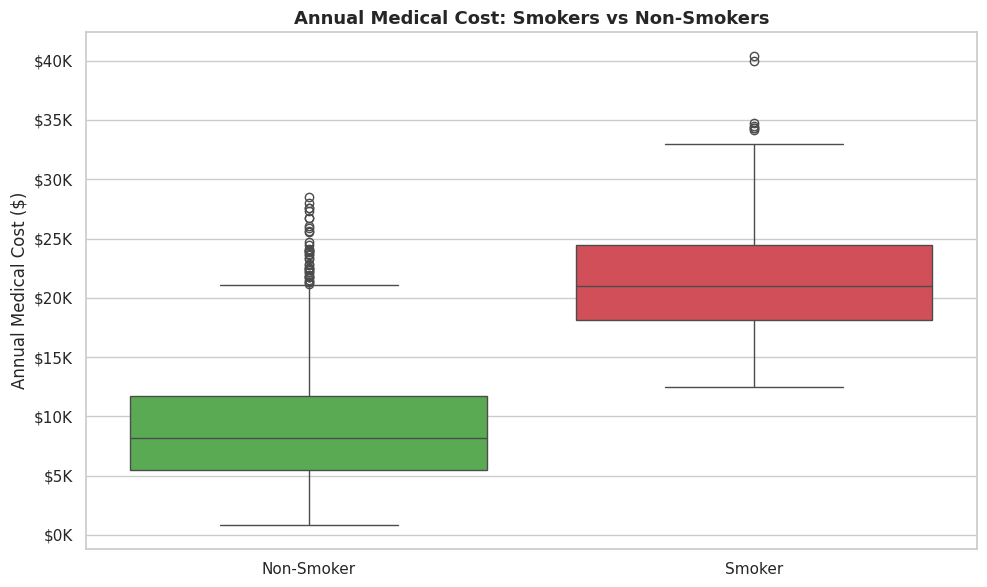

In [15]:
# Box plot comparing the full cost distribution between smokers and non-smokers
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x="smoker_label", y="annual_medical_cost", hue="smoker_label",
            palette={"Non-Smoker": "#4CB944", "Smoker": "#E63946"}, ax=ax, legend=False)
ax.set_title("Annual Medical Cost: Smokers vs Non-Smokers")
ax.set_xlabel("")
ax.set_ylabel("Annual Medical Cost ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
plt.tight_layout()
plt.show()

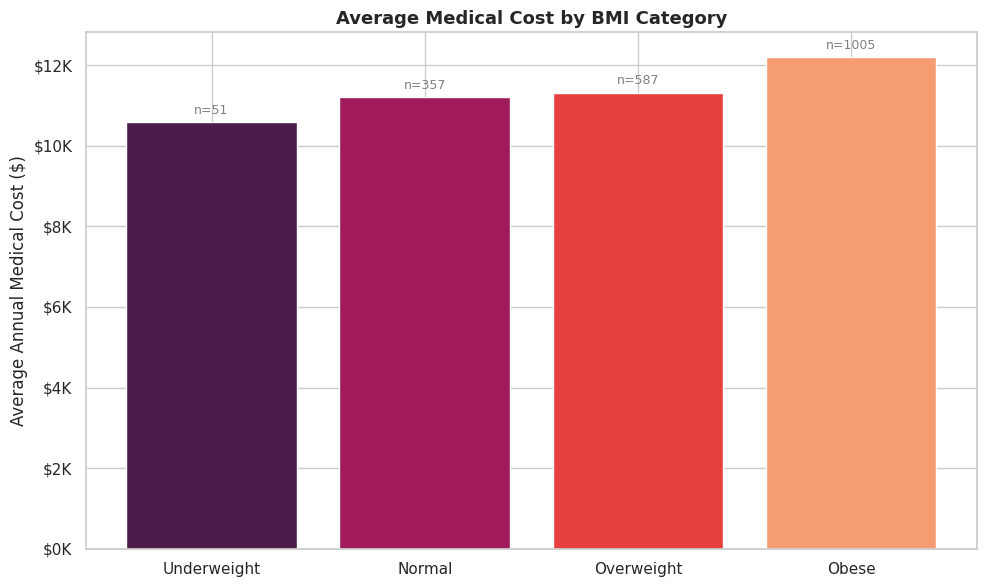

In [16]:
# Bar chart comparing average medical cost across BMI categories (Underweight → Obese)
bmi_analysis = df.groupby("bmi_category", observed=True).agg(total=("bmi_category", "count"), avg_cost=("annual_medical_cost", "mean")).round(2)
bmi_order = ["Underweight", "Normal", "Overweight", "Obese"]
bmi_analysis = bmi_analysis.reindex(bmi_order)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(bmi_analysis.index, bmi_analysis["avg_cost"], color=sns.color_palette("rocket", len(bmi_analysis)))
ax.set_title("Average Medical Cost by BMI Category")
ax.set_ylabel("Average Annual Medical Cost ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
for bar, total in zip(bars, bmi_analysis["total"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200, f"n={total}", ha="center", fontsize=9, color="gray")
plt.tight_layout()
plt.show()

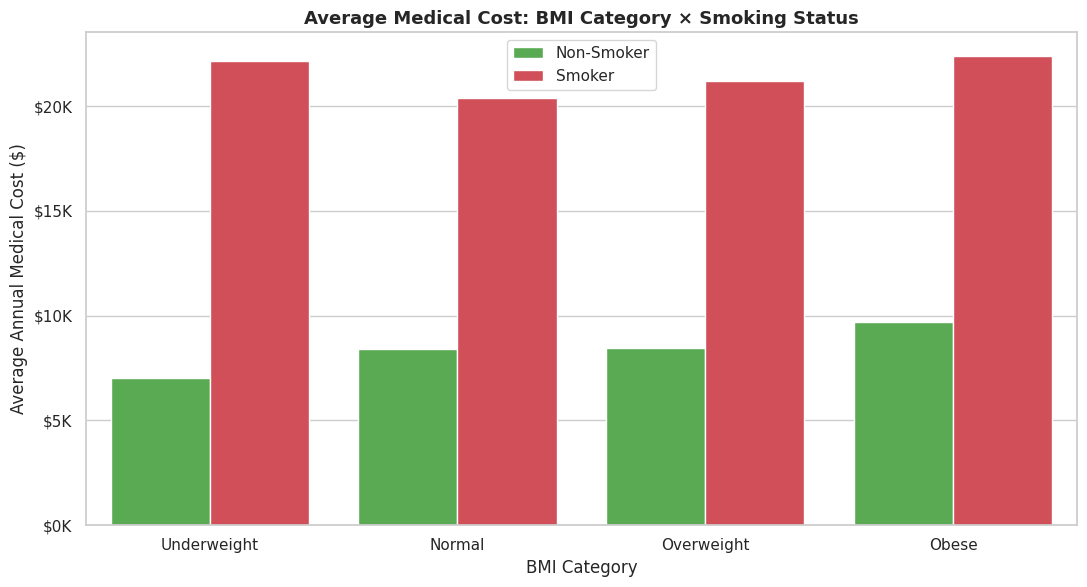

In [17]:
# Grouped bar chart showing how the cost difference between smokers and non-smokers
# varies across each BMI category
combo = df.groupby(["smoker_label", "bmi_category"], observed=True).agg(avg_cost=("annual_medical_cost", "mean")).round(2).reset_index()
bmi_order = ["Underweight", "Normal", "Overweight", "Obese"]
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=combo, x="bmi_category", y="avg_cost", hue="smoker_label", order=bmi_order,
            palette={"Non-Smoker": "#4CB944", "Smoker": "#E63946"}, ax=ax)
ax.set_title("Average Medical Cost: BMI Category × Smoking Status")
ax.set_xlabel("BMI Category")
ax.set_ylabel("Average Annual Medical Cost ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.legend(title="")
plt.tight_layout()
plt.show()

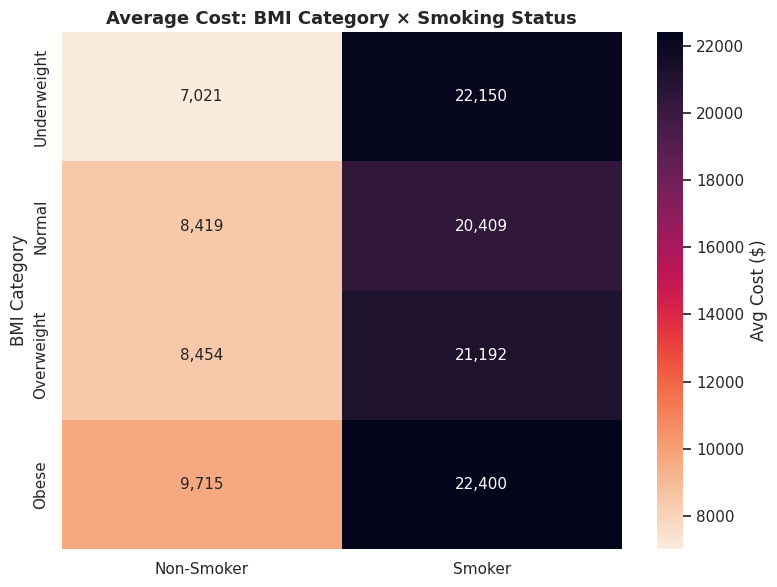

In [18]:
# Heatmap version of the BMI × smoking status cost comparison for quick pattern scanning
pivot2 = pd.pivot_table(df, values="annual_medical_cost", index="bmi_category", columns="smoker_label", aggfunc="mean", observed=True).round(2)
pivot2 = pivot2.reindex(["Underweight", "Normal", "Overweight", "Obese"])
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot2, annot=True, fmt=",.0f", cmap="rocket_r", ax=ax, cbar_kws={"label": "Avg Cost ($)"})
ax.set_title("Average Cost: BMI Category × Smoking Status")
ax.set_xlabel("")
ax.set_ylabel("BMI Category")
plt.tight_layout()
plt.show()

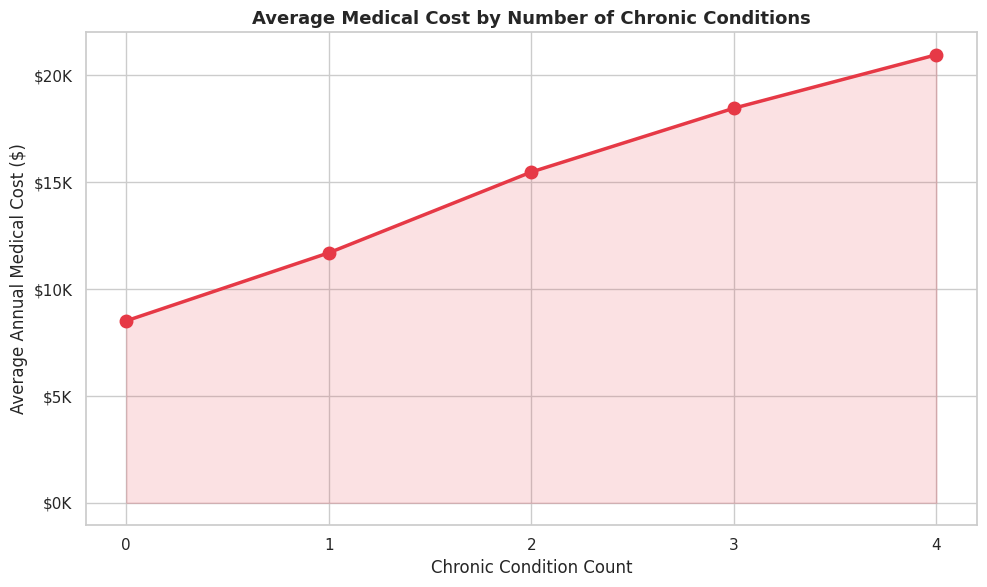

In [19]:
# Line chart showing average medical cost rising as the number of chronic conditions increases
chronic_analysis = df.groupby("chronic_count").agg(total_people=("chronic_count", "count"), avg_cost=("annual_medical_cost", "mean")).round(2)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(chronic_analysis.index, chronic_analysis["avg_cost"], marker="o", linewidth=2.5, markersize=9, color=ACCENT2)
ax.fill_between(chronic_analysis.index, chronic_analysis["avg_cost"], alpha=0.15, color=ACCENT2)
ax.set_title("Average Medical Cost by Number of Chronic Conditions")
ax.set_xlabel("Chronic Condition Count")
ax.set_ylabel("Average Annual Medical Cost ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_xticks(chronic_analysis.index)
plt.tight_layout()
plt.show()

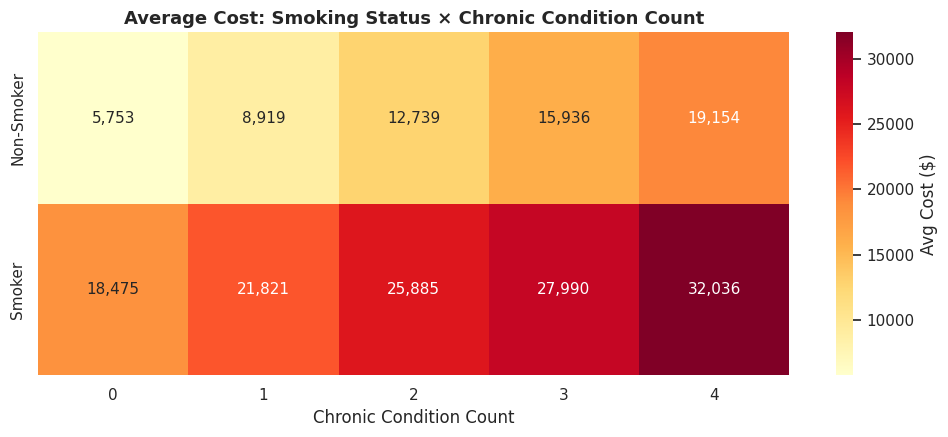

In [20]:
# Heatmap combining smoking status and chronic condition count to highlight the highest-cost corner
smoker_chronic = df.groupby(["smoker_label", "chronic_count"]).agg(avg_cost=("annual_medical_cost", "mean")).round(2).reset_index()
pivot1 = smoker_chronic.pivot(index="smoker_label", columns="chronic_count", values="avg_cost")
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(pivot1, annot=True, fmt=",.0f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "Avg Cost ($)"})
ax.set_title("Average Cost: Smoking Status × Chronic Condition Count")
ax.set_xlabel("Chronic Condition Count")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

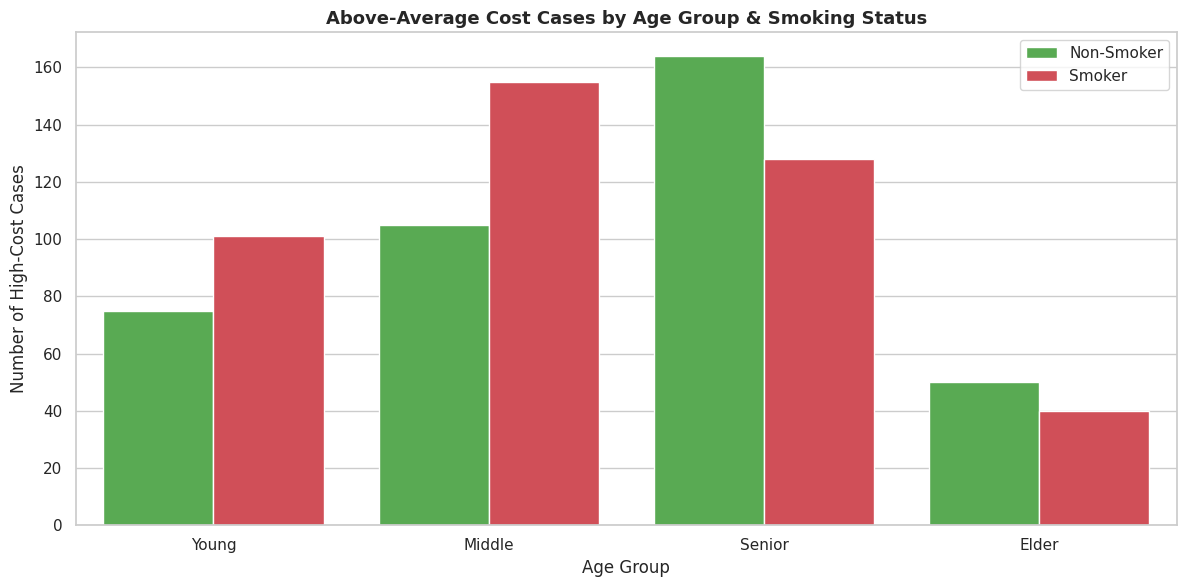

In [21]:
# Grouped bar chart counting above-average-cost cases by age group and smoking status
avg_cost = df["annual_medical_cost"].mean()
high_cost = df[df["annual_medical_cost"] > avg_cost]
result = high_cost.groupby(["smoker_label", "sex", "age_group"], observed=True).size().reset_index(name="high_cost_cases")
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=result, x="age_group", y="high_cost_cases", hue="smoker_label",
            palette={"Non-Smoker": "#4CB944", "Smoker": "#E63946"}, ax=ax,
            order=["Young", "Middle", "Senior", "Elder"], errorbar=None, estimator=sum)
ax.set_title("Above-Average Cost Cases by Age Group & Smoking Status")
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of High-Cost Cases")
ax.legend(title="")
plt.tight_layout()
plt.show()

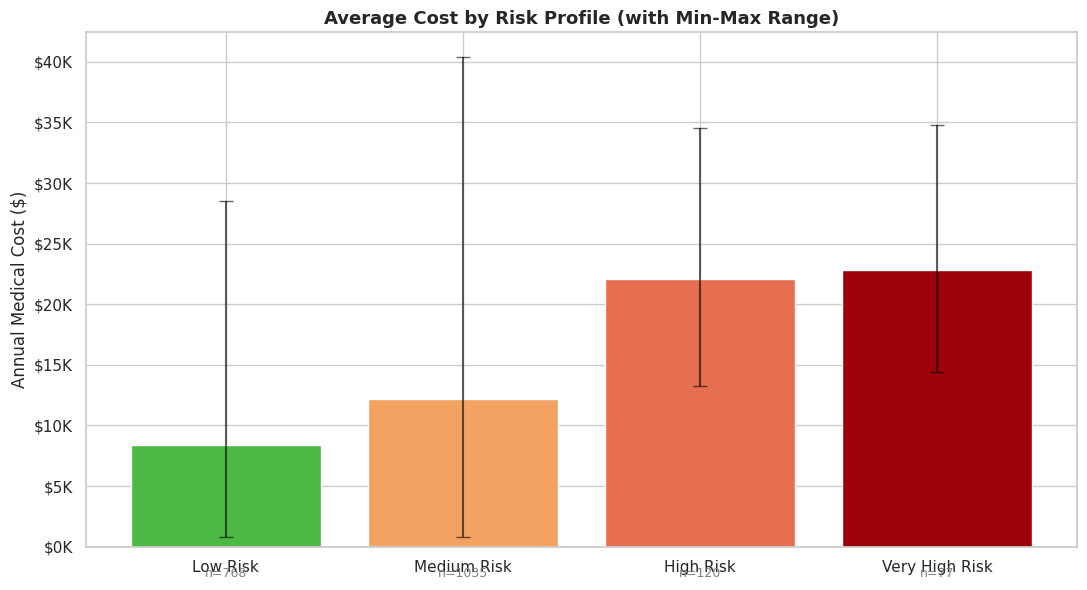

In [22]:
# Bar chart of average cost per risk tier (Low → Very High), with error bars showing
# the min-to-max range and sample sizes labeled below each bar
risk_analysis = df.groupby("risk_profile", observed=True).agg(
    total_people=("risk_profile", "count"), avg_cost=("annual_medical_cost", "mean"),
    min_cost=("annual_medical_cost", "min"), max_cost=("annual_medical_cost", "max")
).round(2)
risk_order = ["Low Risk", "Medium Risk", "High Risk", "Very High Risk"]
risk_analysis = risk_analysis.reindex(risk_order)
fig, ax = plt.subplots(figsize=(11, 6))
colors_risk = ["#4CB944", "#F4A261", "#E76F51", "#9D0208"]
bars = ax.bar(risk_analysis.index, risk_analysis["avg_cost"], color=colors_risk)
ax.errorbar(risk_analysis.index, risk_analysis["avg_cost"],
            yerr=[risk_analysis["avg_cost"]-risk_analysis["min_cost"], risk_analysis["max_cost"]-risk_analysis["avg_cost"]],
            fmt="none", ecolor="black", capsize=5, alpha=0.6)
ax.set_title("Average Cost by Risk Profile (with Min-Max Range)")
ax.set_ylabel("Annual Medical Cost ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
for bar, total in zip(bars, risk_analysis["total_people"]):
    ax.text(bar.get_x()+bar.get_width()/2, -2500, f"n={total}", ha="center", fontsize=9, color="gray")
plt.tight_layout()
plt.show()

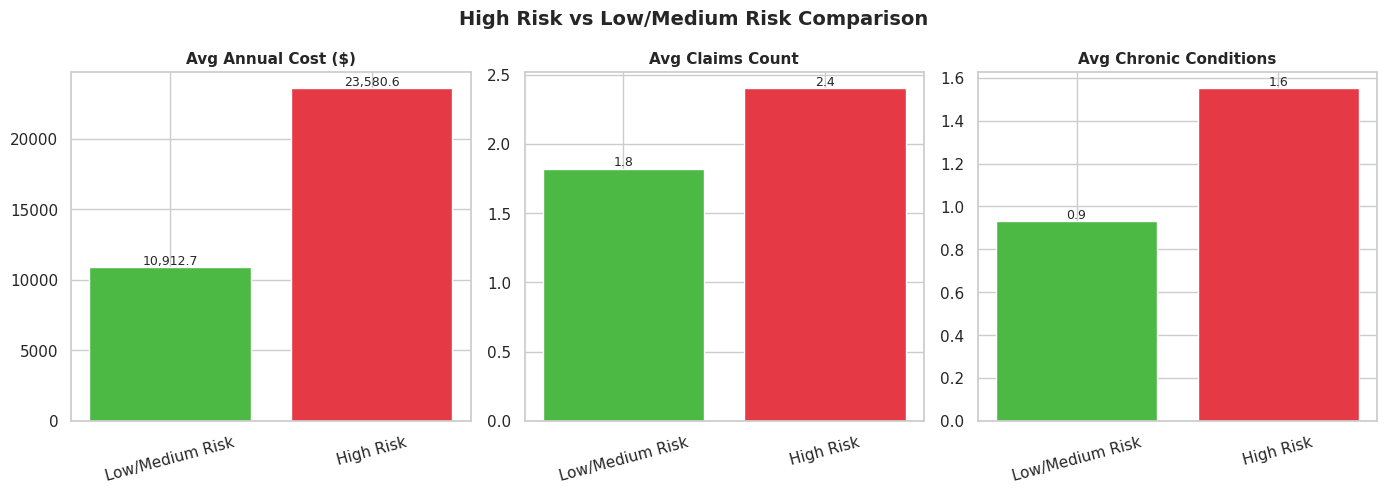

In [23]:
# Three-panel bar chart comparing high-risk vs low-risk members on cost, claims count,
# and number of chronic conditions
risk_analysis2 = df.groupby("is_high_risk").agg(
    avg_cost=("annual_medical_cost", "mean"), avg_claims=("claims_count", "mean"), avg_chronic=("chronic_count", "mean")
).round(2)
risk_analysis2.index = ["Low/Medium Risk", "High Risk"]
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = [("avg_cost", "Avg Annual Cost ($)"), ("avg_claims", "Avg Claims Count"), ("avg_chronic", "Avg Chronic Conditions")]
colors_hr = ["#4CB944", "#E63946"]
for ax, (col, title) in zip(axes, metrics):
    bars = ax.bar(risk_analysis2.index, risk_analysis2[col], color=colors_hr)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis="x", rotation=15)
    for bar, val in zip(bars, risk_analysis2[col]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f"{val:,.1f}", ha="center", va="bottom", fontsize=9)
fig.suptitle("High Risk vs Low/Medium Risk Comparison", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

 Correlations & Cost Decile Analysis

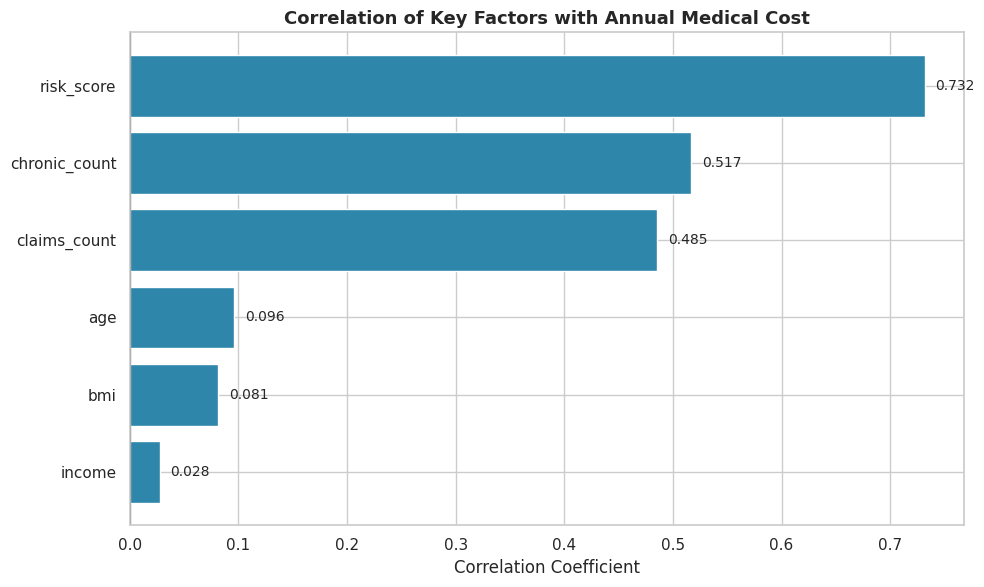

In [24]:
# Horizontal bar chart ranking key factors by their correlation strength with annual medical cost
factors = ["age", "bmi", "income", "risk_score", "chronic_count", "claims_count"]
corrs = {col: df[col].corr(df["annual_medical_cost"]) for col in factors}
corr_series = pd.Series(corrs).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
colors_corr = ["#E63946" if v < 0 else "#2E86AB" for v in corr_series]
ax.barh(corr_series.index, corr_series.values, color=colors_corr)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlation of Key Factors with Annual Medical Cost")
ax.set_xlabel("Correlation Coefficient")
for i, v in enumerate(corr_series.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f"{v:.3f}", va="center", ha="left" if v >= 0 else "right", fontsize=10)
plt.tight_layout()
plt.show()

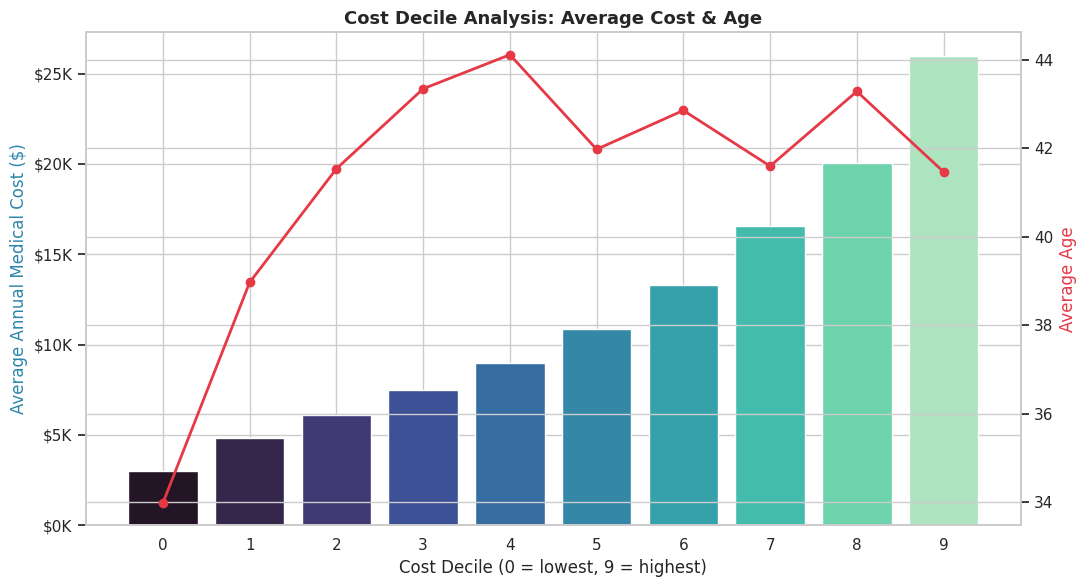

In [25]:
# Dual-axis chart: bars for average cost per decile and a line for average age per decile
decile_analysis = df.groupby("cost_decile").agg(
    total=("cost_decile", "count"), avg_cost=("annual_medical_cost", "mean"),
    avg_age=("age", "mean"), avg_bmi=("bmi", "mean")
).round(2)
fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.bar(decile_analysis.index, decile_analysis["avg_cost"], color=sns.color_palette("mako", len(decile_analysis)))
ax1.set_xlabel("Cost Decile (0 = lowest, 9 = highest)")
ax1.set_ylabel("Average Annual Medical Cost ($)", color=ACCENT)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax1.set_xticks(decile_analysis.index)
ax2 = ax1.twinx()
ax2.plot(decile_analysis.index, decile_analysis["avg_age"], color=ACCENT2, marker="o", linewidth=2, label="Avg Age")
ax2.set_ylabel("Average Age", color=ACCENT2)
ax1.set_title("Cost Decile Analysis: Average Cost & Age")
plt.tight_layout()
plt.show()

## Financials: Premiums, Loss Ratio & Provider Quality

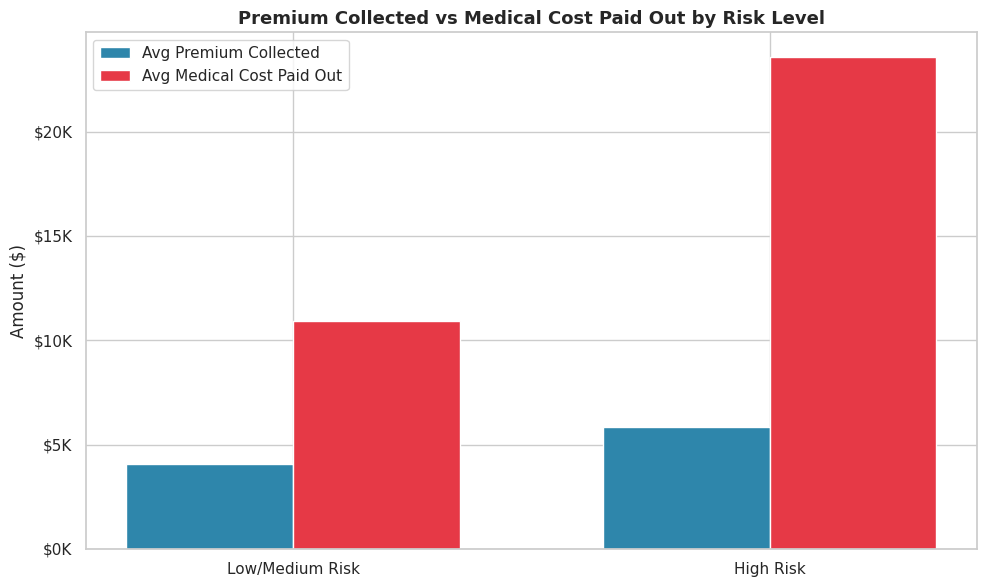

In [26]:
# Grouped bar chart comparing average premium collected vs average cost paid out
# for high-risk vs low-risk members
premium_risk = df.groupby("is_high_risk").agg(avg_premium=("annual_premium", "mean"), avg_cost=("annual_medical_cost", "mean")).round(2)
premium_risk.index = ["Low/Medium Risk", "High Risk"]
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(premium_risk))
width = 0.35
ax.bar(x - width/2, premium_risk["avg_premium"], width, label="Avg Premium Collected", color=ACCENT)
ax.bar(x + width/2, premium_risk["avg_cost"], width, label="Avg Medical Cost Paid Out", color=ACCENT2)
ax.set_xticks(x)
ax.set_xticklabels(premium_risk.index)
ax.set_ylabel("Amount ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_title("Premium Collected vs Medical Cost Paid Out by Risk Level")
ax.legend()
plt.tight_layout()
plt.show()

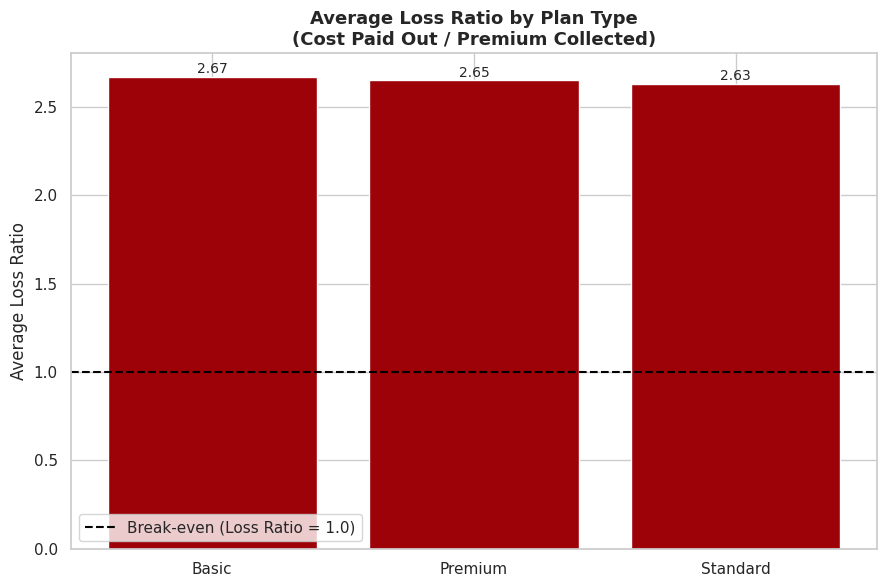

In [27]:
# Bar chart of average loss ratio (cost ÷ premium) by plan type,
# with a dashed line marking the break-even point at 1.0
loss_by_plan = df.groupby("plan_type").agg(avg_loss_ratio=("loss_ratio", "mean")).round(2).sort_values("avg_loss_ratio", ascending=False)
fig, ax = plt.subplots(figsize=(9, 6))
colors_plan = ["#9D0208" if v > 1 else "#4CB944" for v in loss_by_plan["avg_loss_ratio"]]
bars = ax.bar(loss_by_plan.index, loss_by_plan["avg_loss_ratio"], color=colors_plan)
ax.axhline(1, color="black", linestyle="--", linewidth=1.5, label="Break-even (Loss Ratio = 1.0)")
ax.set_title("Average Loss Ratio by Plan Type\n(Cost Paid Out / Premium Collected)")
ax.set_ylabel("Average Loss Ratio")
for bar, val in zip(bars, loss_by_plan["avg_loss_ratio"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f"{val:.2f}", ha="center", fontsize=10)
ax.legend()
plt.tight_layout()
plt.show()

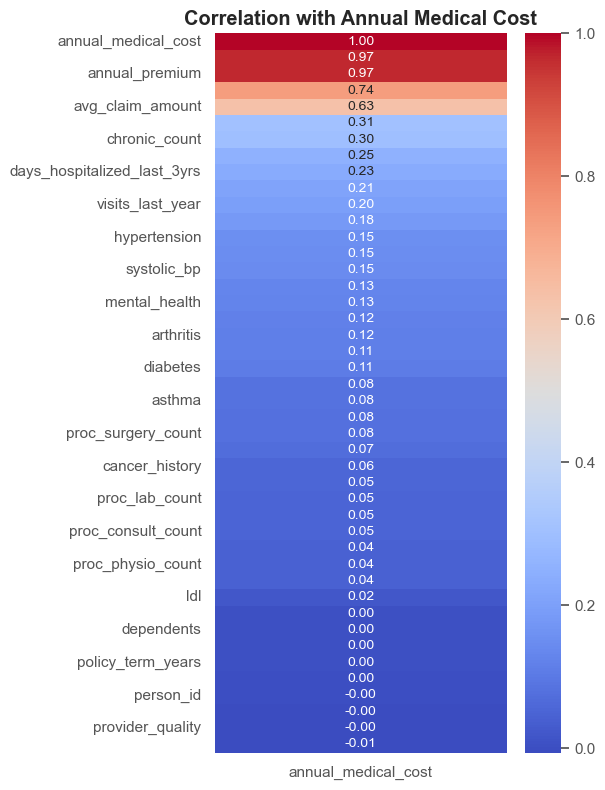

In [24]:
# Heatmap of correlations between all numeric features and annual medical cost
corr_target = (
    numeric_df.corr()[['annual_medical_cost']]
    .sort_values(by='annual_medical_cost', ascending=False)
)

plt.figure(figsize=(6,8))

sns.heatmap(
    corr_target,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation with Annual Medical Cost')
plt.tight_layout()
plt.show()

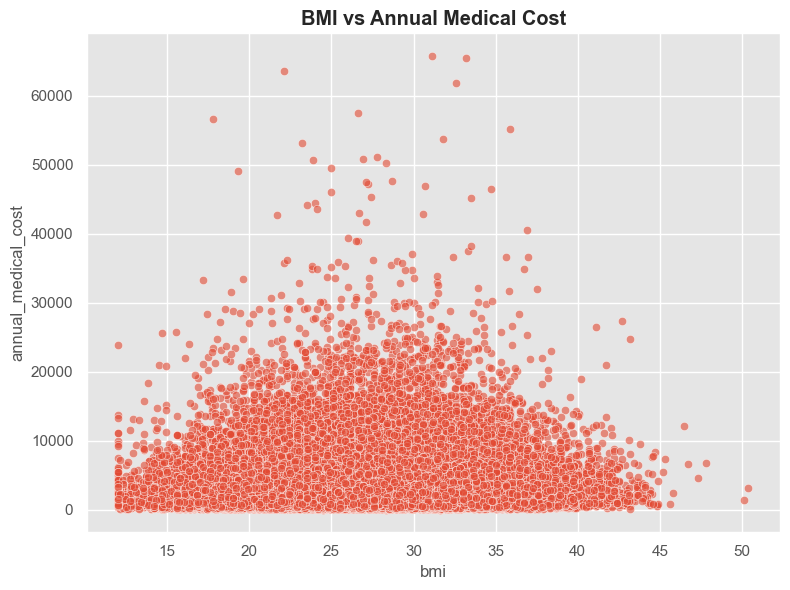

In [26]:
# Scatter plot of BMI vs annual medical cost to visualize the relationship between weight and spend
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='bmi',
    y='annual_medical_cost',
    alpha=0.6
)

plt.title('BMI vs Annual Medical Cost')
plt.tight_layout()
plt.show()

## Claims Count Distribution

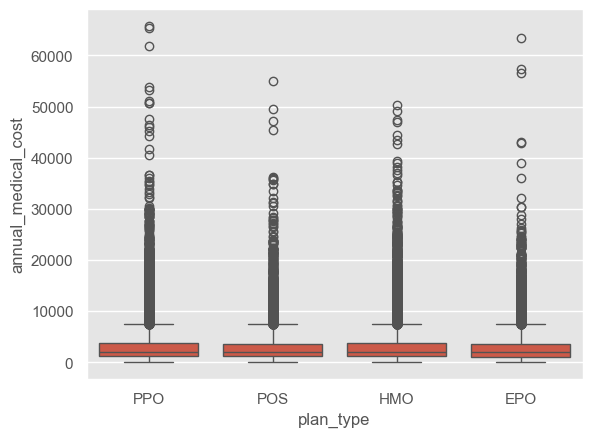

In [28]:
# Box plot comparing annual medical cost distributions across different plan types
sns.boxplot(
    data=df,
    x='plan_type',
    y='annual_medical_cost'
)
plt.show()

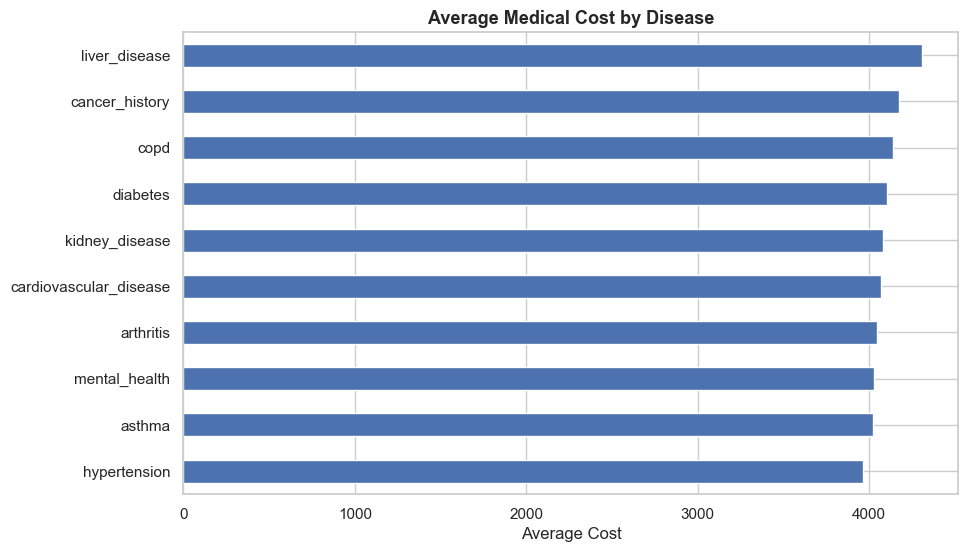

In [33]:
# Bar chart showing the average medical cost for members who have each specific disease
diseases = [
    'hypertension','diabetes','asthma','copd',
    'cardiovascular_disease','cancer_history',
    'kidney_disease','liver_disease',
    'arthritis','mental_health'
]

disease_cost = {}

for disease in diseases:
    disease_cost[disease] = df.groupby(disease)['annual_medical_cost'].mean()[1]

disease_cost = pd.Series(disease_cost).sort_values()

plt.figure(figsize=(10,6))
disease_cost.plot(kind='barh')

plt.title('Average Medical Cost by Disease')
plt.xlabel('Average Cost')
plt.show()

## cost distributions across different insurance network tiers

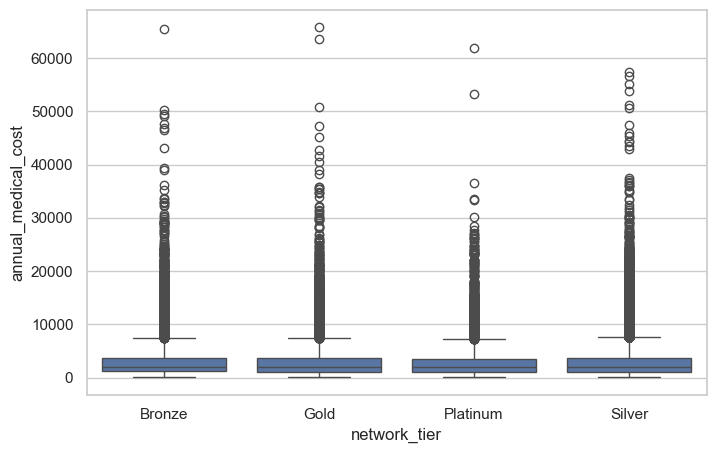

In [35]:
# Box plot comparing cost distributions across different insurance network tiers
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='network_tier',
    y='annual_medical_cost'
)

plt.show()

## deductible amount vs annual medical cost

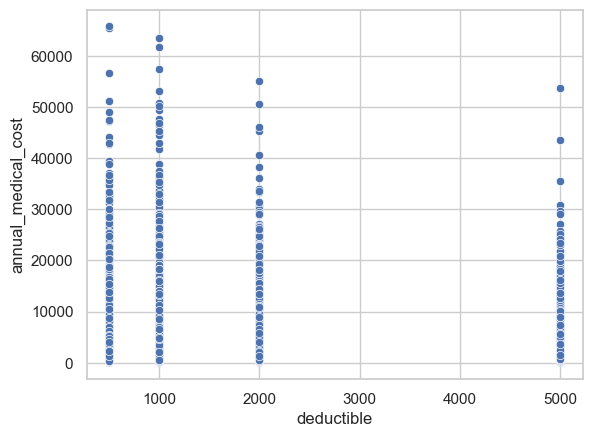

In [36]:
# Scatter plot of deductible amount vs annual medical cost
sns.scatterplot(
    data=df,
    x='deductible',
    y='annual_medical_cost'
)

plt.show()

## cost between urban and rural members

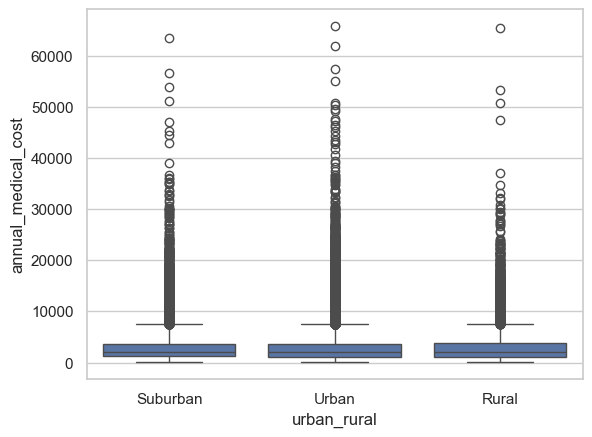

In [39]:
# Box plot comparing cost between urban and rural members
sns.boxplot(
    data=df,
    x='urban_rural',
    y='annual_medical_cost'
)

plt.show()

## how past hospitalizations predict future medical cost

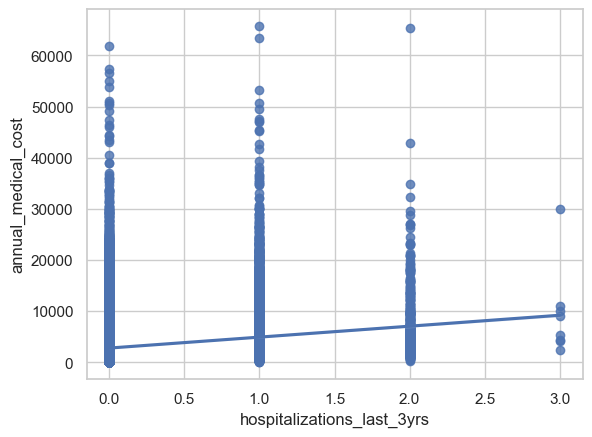

In [41]:
# Regression plot showing how past hospitalizations predict future medical cost
sns.regplot(
    data=df,
    x='hospitalizations_last_3yrs',
    y='annual_medical_cost'
)

plt.show()

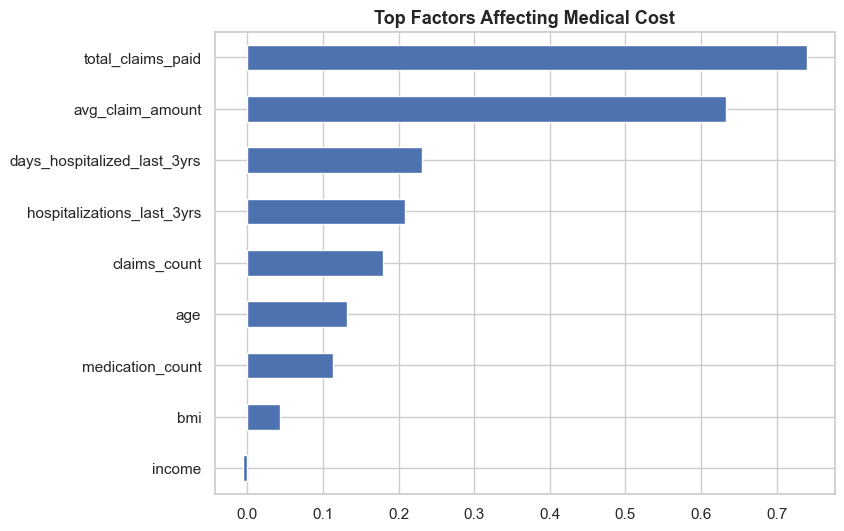

In [43]:
# Horizontal bar chart ranking the top factors that correlate most strongly with medical cost
cols = [
    'age',
    'bmi',
    'claims_count',
    'income',
    'hospitalizations_last_3yrs',
    'days_hospitalized_last_3yrs',
    'medication_count',
    'avg_claim_amount',
    'total_claims_paid',
    'annual_medical_cost'
]

corr = df[cols].corr()['annual_medical_cost'].sort_values()

plt.figure(figsize=(8,6))
corr.drop('annual_medical_cost').plot(kind='barh')

plt.title('Top Factors Affecting Medical Cost')
plt.show()

## how total days hospitalized in the past 3 years predicts annual cost

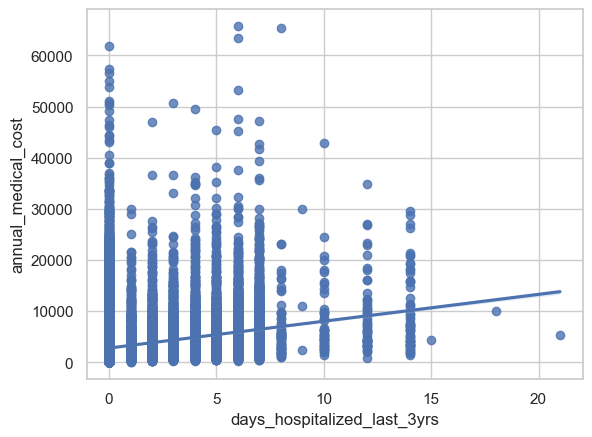

In [45]:
# Regression plot showing how total days hospitalized in the past 3 years predicts annual cost
sns.regplot(
    data=df,
    x='days_hospitalized_last_3yrs',
    y='annual_medical_cost'
)

plt.show()